In [1]:
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display
from PIL import Image as PILImage, ImageDraw

Imagen seleccionada: 14042507CN_jpg.rf.3fb2526edeac9c97310b2f71145f0d30.jpg


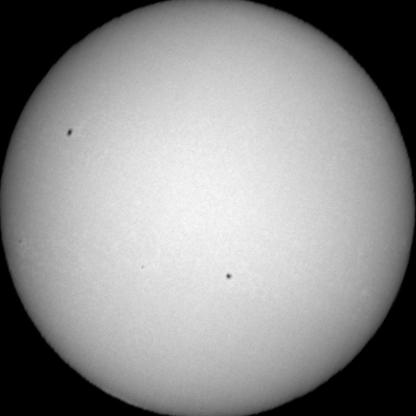

In [21]:
images_path = Path('dataset/OGAUC/train/images')
image_files = list(images_path.glob('*.jpg'))
#img_path = random.choice(image_files)
img_path = Path('dataset/OGAUC/train/images/14042507CN_jpg.rf.3fb2526edeac9c97310b2f71145f0d30.jpg')
# Mostrar la imagen original
print(f"Imagen seleccionada: {img_path.name}")
display(Image(filename=str(img_path)))

In [3]:
def interactive_pixel_intensity_threshold(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    cv2.namedWindow('Pixel Intensity Threshold')
    cv2.createTrackbar('Threshold', 'Pixel Intensity Threshold', 60, 255, lambda x: None)

    while True:
        thresh_val = cv2.getTrackbarPos('Threshold', 'Pixel Intensity Threshold')
        _, mask = cv2.threshold(img, thresh_val, 255, cv2.THRESH_BINARY_INV)
        cv2.imshow('Pixel Intensity Threshold', mask)
        k = cv2.waitKey(1) & 0xFF
        if k == 27:  # ESC para salir
            break
    cv2.destroyAllWindows()

# Uso:
interactive_pixel_intensity_threshold(img_path)

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:2564: error: (-27:Null pointer) NULL window: 'Pixel Intensity Threshold' in function 'cvGetTrackbarPos'


In [22]:
def segment_sunspot_pixel_intensity(image_path, threshold=60):
    """
    Segmenta sunspots usando un umbral fijo de intensidad de píxel.
    threshold: valor entre 0 (negro) y 255 (blanco). Ajusta según tus imágenes.
    """
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    # Las manchas solares son más oscuras, así que seleccionamos los píxeles por debajo del umbral
    _, mask = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY_INV)
    pil_img = PILImage.fromarray(mask)
    return pil_img

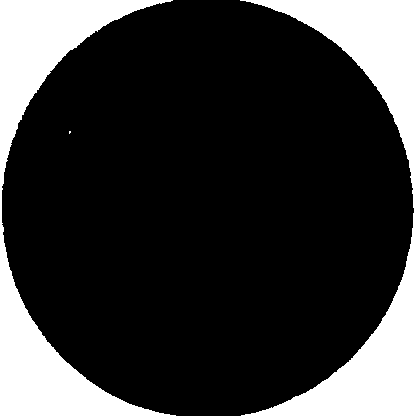

In [23]:
seg_img_intensity = segment_sunspot_pixel_intensity(img_path, threshold=70)
display(seg_img_intensity)

In [24]:
def get_bboxes_from_mask(mask, min_spot_area=2, max_spot_area=None):
    # Asegúrate de que mask es un array numpy uint8
    if not isinstance(mask, np.ndarray):
        mask = np.array(mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_spot_area and (max_spot_area is None or area < max_spot_area):
            x, y, w, h = cv2.boundingRect(cnt)
            bboxes.append((x, y, w, h))
    return bboxes

In [25]:
def draw_bboxes_on_image(image_path, bboxes):
    pil_img = PILImage.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(pil_img)
    for (x, y, w, h) in bboxes:
        draw.rectangle([x, y, x+w, y+h], outline="red", width=2)
    return pil_img

In [26]:
def expand_bboxes(bboxes, img_shape, margin=5):
    """
    Expande cada bbox por 'margin' píxeles en cada dirección, sin salirse de la imagen.
    bboxes: lista de (x, y, w, h)
    img_shape: (alto, ancho)
    """
    h, w = img_shape
    expanded = []
    for (x, y, bw, bh) in bboxes:
        x0 = max(x - margin, 0)
        y0 = max(y - margin, 0)
        x1 = min(x + bw + margin, w)
        y1 = min(y + bh + margin, h)
        expanded.append((x0, y0, x1 - x0, y1 - y0))
    return expanded

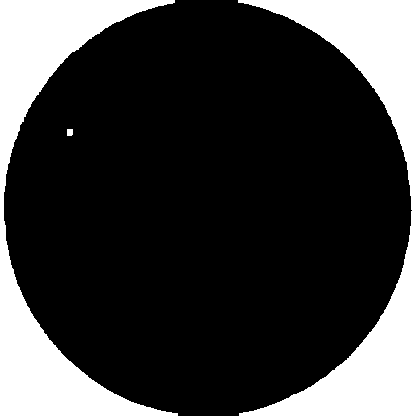

In [27]:
mask_np = np.array(seg_img_intensity)

# DILATAR la máscara original para agrandar la mancha blanca
kernel = np.ones((5, 5), np.uint8)  # Prueba también con (3,3)
mask_dilated = cv2.dilate(mask_np, kernel, iterations=1)
display(PILImage.fromarray(mask_dilated))


Bounding boxes: [(67, 129, 6, 7)]


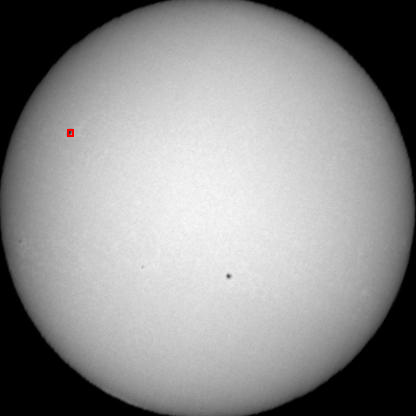

In [28]:
mask_np = np.array(mask_dilated)

bboxes = get_bboxes_from_mask(mask_np, min_spot_area=2, max_spot_area=18000)
print("Bounding boxes:", bboxes)

img_with_bboxes = draw_bboxes_on_image(str(img_path), bboxes)
display(img_with_bboxes)

Bounding boxes (expandidos): [(62, 124, 16, 17)]


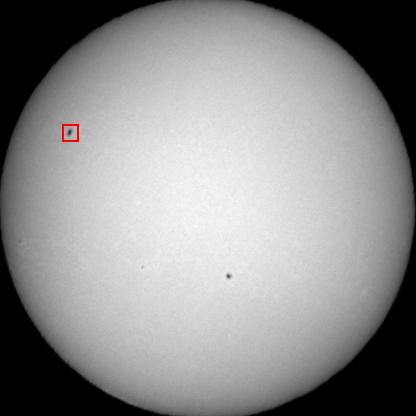

In [29]:
bboxes_expanded = expand_bboxes(bboxes, mask_np.shape, margin=5)
print("Bounding boxes (expandidos):", bboxes_expanded)

img_with_bboxes = draw_bboxes_on_image(str(img_path), bboxes_expanded)
display(img_with_bboxes)

In [ ]:

h, w = mask_dilated.shape

def show_dummy_bbox(radius):
    # Crea una máscara negra y dibuja un círculo blanco en el centro
    dummy_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(dummy_mask, (w//2, h//2), radius, 255, -1)
    bboxes = get_bboxes_from_mask(dummy_mask, min_spot_area=2, max_spot_area=None)
    img = cv2.imread(str(img_path))
    for (x, y, w_box, h_box) in bboxes:
        cv2.rectangle(img, (x, y), (x+w_box, y+h_box), (0, 0, 255), 2)
        area = w_box * h_box
        cv2.putText(img, f"Area: {area}", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2)
    cv2.imshow('Dummy Bounding Box', img)

def on_trackbar(val):
    if val < 1:
        val = 1
    show_dummy_bbox(val)

cv2.namedWindow('Dummy Bounding Box')
cv2.createTrackbar('radius', 'Dummy Bounding Box', 1, min(h, w)//2, on_trackbar)
show_dummy_bbox(1)

while True:
    if cv2.waitKey(1) & 0xFF == 27:  # ESC para salir
        break
cv2.destroyAllWindows()